In [1]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

C:\Users\jarvi\Desktop\amk\codes\exoplanet-api\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
search_result=lk.search_lightcurve("Kepler-8b", mission="Kepler", cadence="long")
print(search_result)

SearchResult containing 19 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 00 2009     Kepler    1800                kplr006922244      0.0
  1 Kepler Quarter 01 2009     Kepler    1800                kplr006922244      0.0
  2 Kepler Quarter 02 2009     Kepler    1800                kplr006922244      0.0
  3 Kepler Quarter 03 2009     Kepler    1800                kplr006922244      0.0
  4 Kepler Quarter 04 2010     Kepler    1800                kplr006922244      0.0
  5 Kepler Quarter 05 2010     Kepler    1800                kplr006922244      0.0
  6 Kepler Quarter 06 2010     Kepler    1800                kplr006922244      0.0
  7 Kepler Quarter 07 2010     Kepler    1800                kplr006922244      0.0
  8 Kepler Quarter 08 2011     Ke

In [3]:
lc = search_result[0].download()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

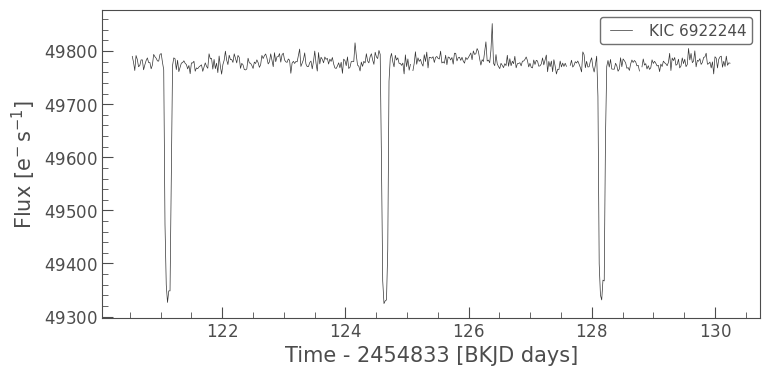

In [4]:
lc.plot()

In [5]:
lc_clean=lc.remove_nans().remove_outliers().flatten()
lc_clean.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

In [6]:
bls=lc_clean.to_periodogram(method="bls",period=np.linspace(0.5,10,10000))

In [7]:
max_period=bls.period_at_max_power
max_transit=bls.transit_time_at_max_power
max_duration=bls.duration_at_max_power

print("Period:", max_period)
print("Transit time:", max_transit)
print("Duration:", max_duration)

Period: 0.843934393439344 d
Transit time: 120.73979406206782
Duration: 0.33 d


In [8]:
bls.plot()

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

In [9]:
folded = lc_clean.fold(period=bls.period_at_max_power, epoch_time=bls.transit_time_at_max_power)
folded.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>